In [72]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_semi_sticky_wages import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

model = ModelClass()

par = model.par
sim = model.sim

model.solve(do_print=True)

params_to_latex(par)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Convergence achieved at iteration 624 with eps = 6.02e-09


The model converges to the steady state:

In [73]:
print(f"Old workers supply in high jobs: {[f'{x:.2f}' for x in par.l_h_ss]}")
print(f"Old workers supply in low jobs: {[f'{x:.2f}' for x in par.l_l_ss]}")
print(f"Wage of old workers in high jobs: {[f'{x:.2f}' for x in par.wage_h_ss]}")
print(f"Wage of old workers in low jobs: {[f'{x:.2f}' for x in par.wage_l_ss]}")

Old workers supply in high jobs: ['0.11', '0.11', '0.11', '0.11', '0.11', '0.11', '0.11', '0.11', '0.11', '0.11', '0.11', '0.11', '0.11', '0.11', '0.10', '0.10', '0.10', '0.09', '0.08', '0.08', '0.07', '0.05', '0.04', '0.03', '0.02', '0.01', '0.01', '0.00', '0.00', '0.00']
Old workers supply in low jobs: ['0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.88', '0.88', '0.88', '0.87', '0.85', '0.83', '0.81', '0.77', '0.73', '0.67', '0.60', '0.52', '0.44', '0.34', '0.25', '0.17', '0.10', '0.05', '0.02', '0.01', '0.00']
Wage of old workers in high jobs: ['0.20', '0.20', '0.20', '0.21', '0.21', '0.21', '0.21', '0.22', '0.22', '0.23', '0.23', '0.23', '0.24', '0.24', '0.25', '0.25', '0.25', '0.26', '0.26', '0.27', '0.27', '0.27', '0.28', '0.28', '0.28', '0.29', '0.29', '0.29', '0.29', '0.30']
Wage of old workers in low jobs: ['0.18', '0.18', '0.19', '0.19', '0.19', '0.19', '0.20', '0.20', '0.20', '0.21', '0.21', '0.21', '0.22', '0.22', '0.22', '0.23', '0.23', '0.24', 

First, I check that the model aligns with Bianchi and Paradisi, such that the above is true:

\begin{equation*}
    \frac{\partial\bar{w}_{t}^{y}}{\partial l_{h,t-1}^{y}}=\underset{\text{Career spillovers}<0}{\underbrace{\frac{1}{l_{t}^{y}}\left(\mu^{y}-1\right)w_{\ell}^{y}\frac{\partial l_{h}^{y}}{\partial l_{h,t-1}^{y}}}}+\underset{\text{Wage level}>0}{\underbrace{\left[\frac{1}{l_{t}^{y}}\left(\mu^{y}-1\right)l_{h}^{y}+1\right]\frac{\partial w_{\ell}^{y}}{\partial l_{h,t-1}^{y}}}}
\end{equation*}

I find the same signs as they do:

In [74]:
model.average_wage_change()

Increasing the retirement of older workers increases the wage gap

In [75]:
new_rho_h = model.par.rho_h.copy()

new_rho_h[-5:] = new_rho_h[-5:]*1.5

parameter_names = ["rho_h"]
parameter_values = [new_rho_h]

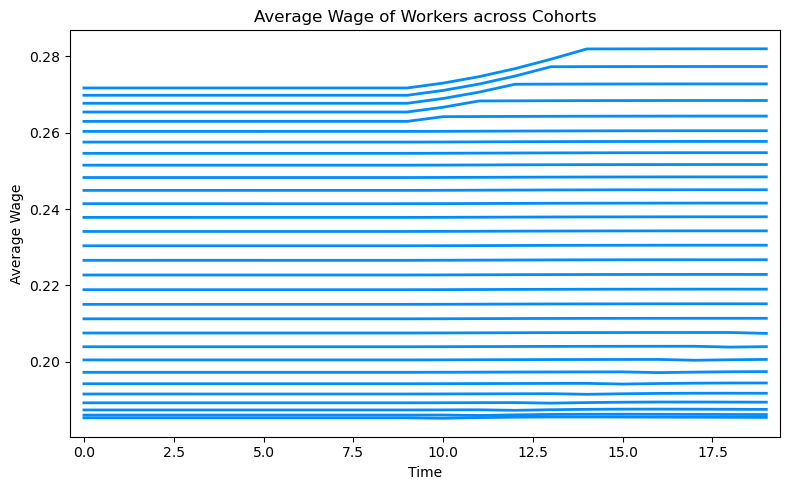

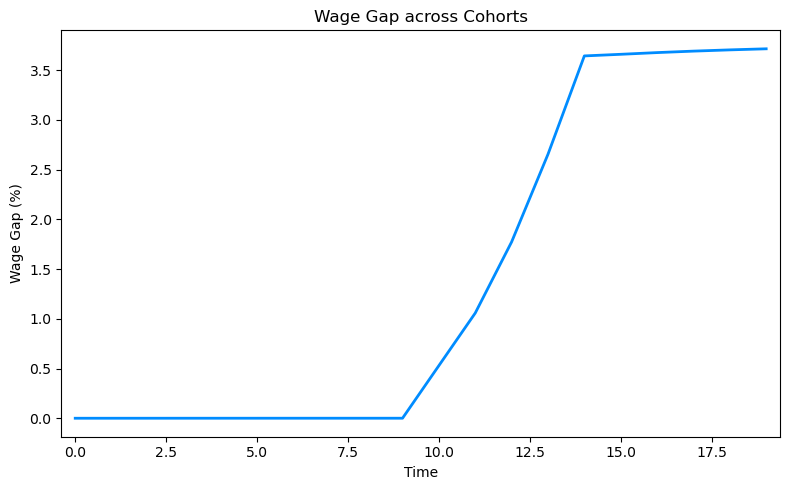

In [76]:
model.simulate_par_shock(parameter_names, parameter_values)

plot_series(model.sim.avg_wage[:, :], title="Average Wage of Workers across Cohorts", ylabel="Average Wage")

wage_gap = (model.sim.avg_wage[:, -1]/model.sim.avg_wage[0, -1] - model.sim.avg_wage[:, 0]/ model.sim.avg_wage[0, 0])*100
plot_series(wage_gap, title="Wage Gap across Cohorts", ylabel="Wage Gap (%)")

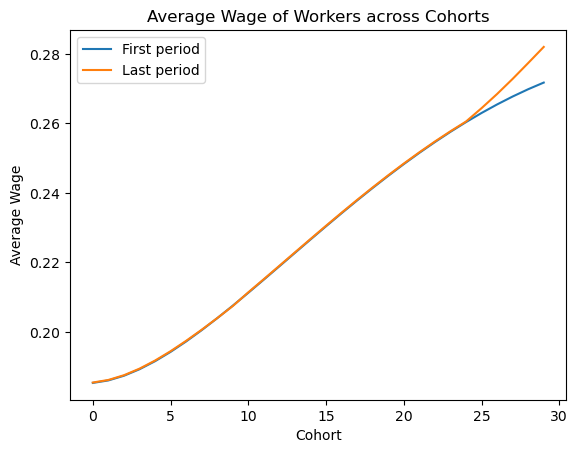

In [77]:
plt.plot(model.sim.avg_wage[0, :], label="First period")
plt.plot(model.sim.avg_wage[-1, :], label="Last period")
plt.title("Average Wage of Workers across Cohorts")
plt.xlabel("Cohort")
plt.ylabel("Average Wage")
plt.legend()


Increasing the number of young workers increases the wage gap

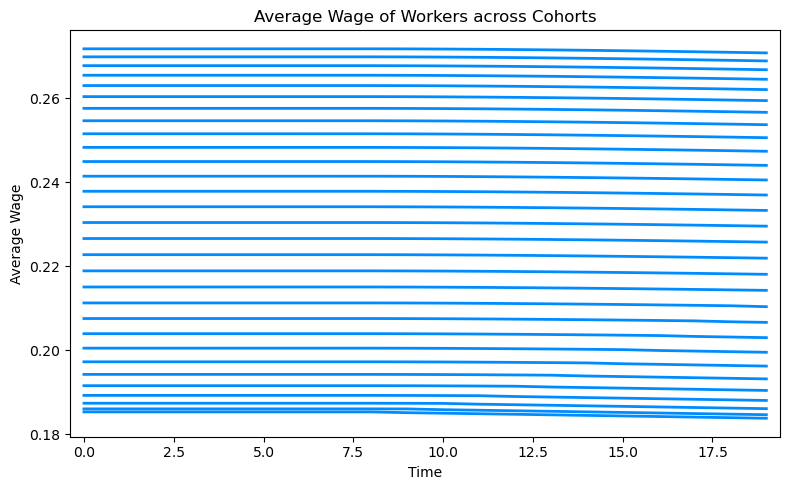

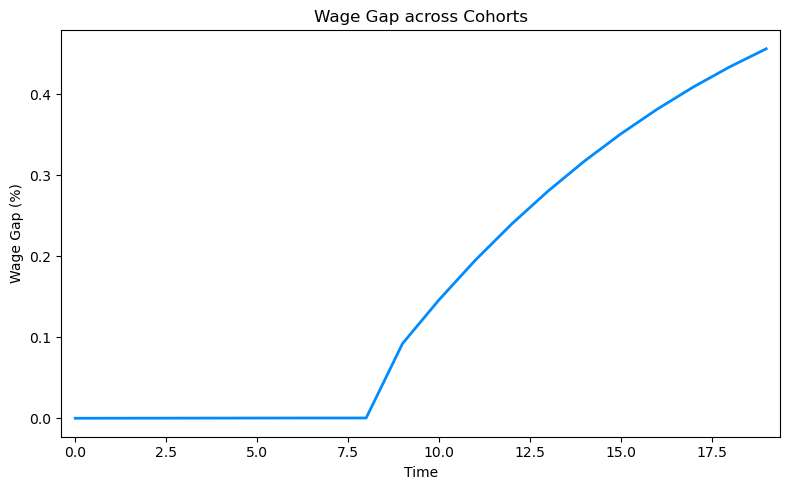

In [79]:
parameter_names = ["N_1"]
parameter_values = [model.par.N_1*1.05]

model.simulate_par_shock(parameter_names, parameter_values)

plot_series(model.sim.avg_wage[:, :], title="Average Wage of Workers across Cohorts", ylabel="Average Wage")

wage_gap = (model.sim.avg_wage[:, -1]/model.sim.avg_wage[0, -1] - model.sim.avg_wage[:, 0]/ model.sim.avg_wage[0, 0])*100
plot_series(wage_gap, title="Wage Gap across Cohorts", ylabel="Wage Gap (%)")